In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kde

Gráfica guardada como: comparativa_distancias_ars.png


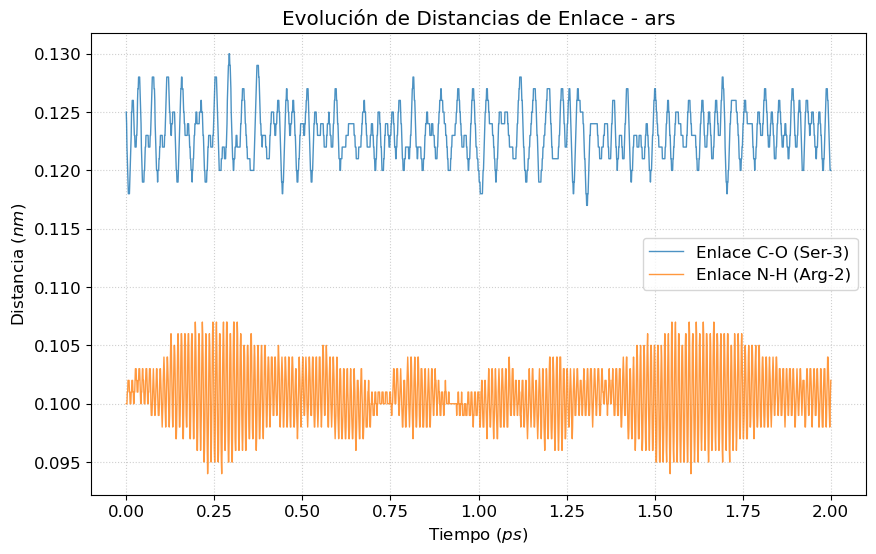

Gráfica guardada como: comparativa_angulos_ars.png


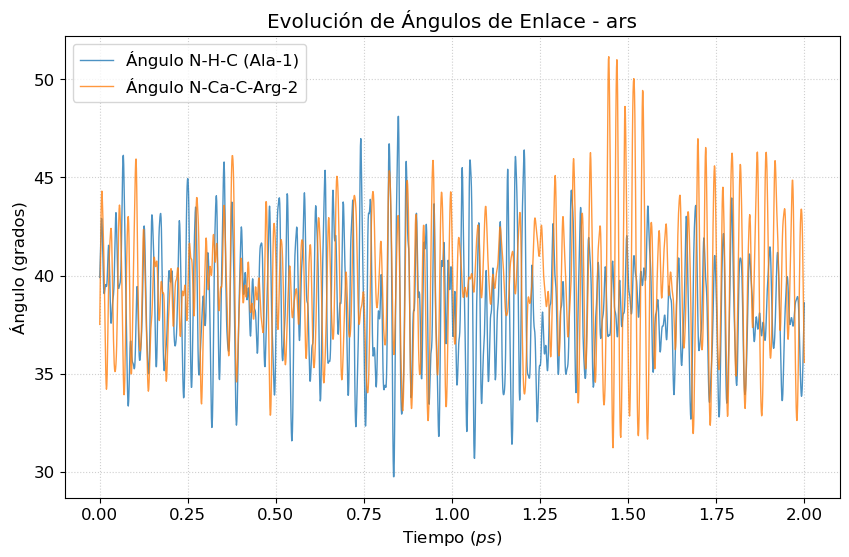

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Configuración de estilo para el informe en LaTeX
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6), 'savefig.dpi': 300})

def load_gmx_xvg(file_path):
    """Carga datos de un archivo .xvg ignorando metadatos de GROMACS"""
    if not os.path.exists(file_path):
        print(f"Error: No se encuentra el archivo {file_path}")
        return None
    return np.loadtxt(file_path, comments=['#', '@'])

def plot_comparison(files, labels, title, ylabel, output_name):
    """Grafica varios archivos en una misma figura"""
    plt.figure()
    
    colors = ['tab:blue', 'tab:orange']
    
    for i, file in enumerate(files):
        data = load_gmx_xvg(file)
        if data is not None:
            # Columna 0: Tiempo, Columna 1: Valor
            plt.plot(data[:, 0], data[:, 1], label=labels[i], color=colors[i], alpha=0.8, linewidth=1)
    
    plt.title(title)
    plt.xlabel('Tiempo ($ps$)')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best')
    
    plt.savefig(output_name, bbox_inches='tight')
    print(f"Gráfica guardada como: {output_name}")
    plt.show()

# Rutas
base_path = r'C:/Users/anton/Desktop/Master/Segundo cuatri/ModeladoMolecular/Tarea/Tarea/400k/4-analysis4/'

# 1. Graficar Distancias de Enlace (dist0 y dist1)
dist_files = [base_path + 'dist0.xvg', base_path + 'dist1.xvg']
dist_labels = ['Enlace C-O (Ser-3)', 'Enlace N-H (Arg-2)'] # Ajusta según tus selecciones
plot_comparison(dist_files, dist_labels, 
                'Evolución de Distancias de Enlace - ars', 
                'Distancia ($nm$)', 
                'comparativa_distancias_ars.png')

# 2. Graficar Ángulos de Enlace (angaver2 y angaver3)
angle_files = [base_path + 'angaver2.xvg', base_path + 'angaver3.xvg']
angle_labels = ['Ángulo N-H-C (Ala-1)', 'Ángulo N-Ca-C-Arg-2'] # Ajusta según tus selecciones
plot_comparison(angle_files, angle_labels, 
                'Evolución de Ángulos de Enlace - ars', 
                'Ángulo (grados)', 
                'comparativa_angulos_ars.png')

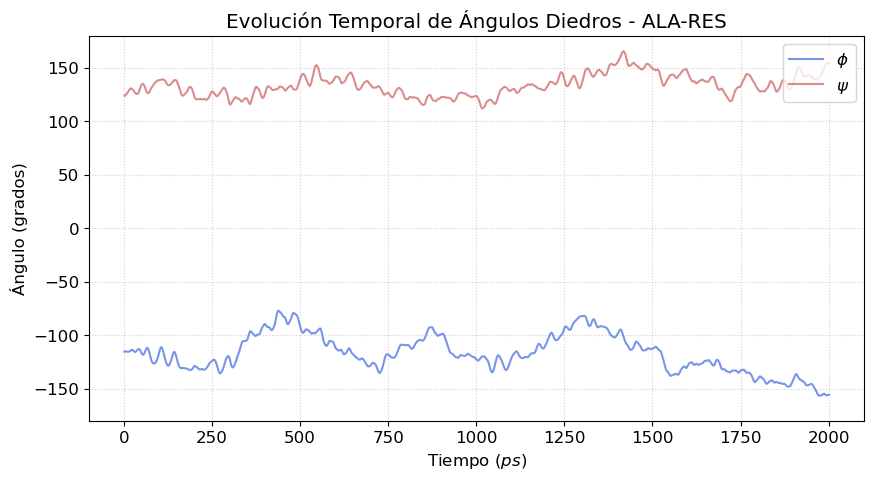

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

def analizar_diedros_ars(file_path, residuo_nombre="ALA-2"):
    try:
        # Cargar datos: Col 0=Tiempo, Col 1=Phi, Col 2=Psi
        data = np.loadtxt(file_path)
        tiempo = data[:, 0]
        phi = data[:, 1]
        psi = data[:, 2]

        # --- GRÁFICO 1: EVOLUCIÓN TEMPORAL (Requisito Informe Básico) ---
        plt.figure(figsize=(10, 5))
        plt.plot(tiempo, phi, label=r'$\phi$', alpha=0.7, color='royalblue')
        plt.plot(tiempo, psi, label=r'$\psi$', alpha=0.7, color='indianred')
        plt.title(f'Evolución Temporal de Ángulos Diedros - {residuo_nombre}')
        plt.xlabel('Tiempo ($ps$)')
        plt.ylabel('Ángulo (grados)')
        plt.ylim(-180, 180)
        plt.legend(loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.savefig(f'evolucion_{residuo_nombre}.png')
        plt.show()



    except Exception as e:
        print(f"Error: {e}. Verifica que el archivo tenga 3 columnas.")

# Uso (Recuerda usar r'ruta' si estás en Windows)
analizar_diedros_ars(r'C:/Users/anton/Desktop/Master/Segundo cuatri/ModeladoMolecular/Tarea/Tarea/400k/4-analysis4/ala-2.dat', residuo_nombre="ALA-RES")

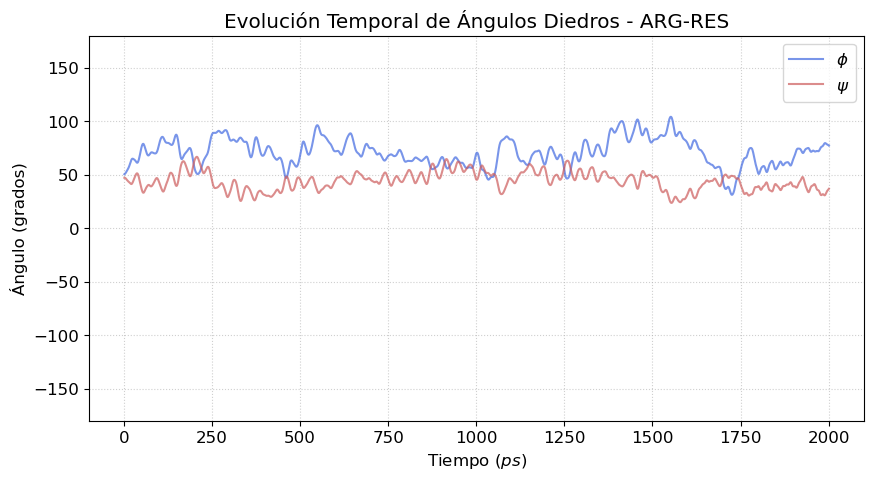

In [10]:
def analizar_diedros_ars(file_path, residuo_nombre="ARG-3"):
    try:
        # Cargar datos: Col 0=Tiempo, Col 1=Phi, Col 2=Psi
        data = np.loadtxt(file_path)
        tiempo = data[:, 0]
        phi = data[:, 1]
        psi = data[:, 2]

        # --- GRÁFICO 1: EVOLUCIÓN TEMPORAL (Requisito Informe Básico) ---
        plt.figure(figsize=(10, 5))
        plt.plot(tiempo, phi, label=r'$\phi$', alpha=0.7, color='royalblue')
        plt.plot(tiempo, psi, label=r'$\psi$', alpha=0.7, color='indianred')
        plt.title(f'Evolución Temporal de Ángulos Diedros - {residuo_nombre}')
        plt.xlabel('Tiempo ($ps$)')
        plt.ylabel('Ángulo (grados)')
        plt.ylim(-180, 180)
        plt.legend(loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.savefig(f'evolucion_{residuo_nombre}.png')
        plt.show()



    except Exception as e:
        print(f"Error: {e}. Verifica que el archivo tenga 3 columnas.")

# Uso (Recuerda usar r'ruta' si estás en Windows)
analizar_diedros_ars(r'C:/Users/anton/Desktop/Master/Segundo cuatri/ModeladoMolecular/Tarea/Tarea/400k/4-analysis4/arg-3.dat', residuo_nombre="ARG-RES")

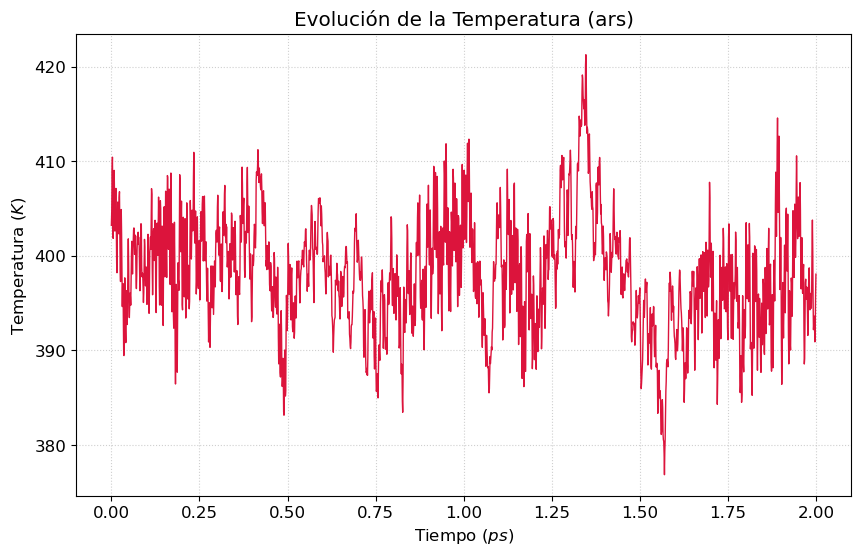

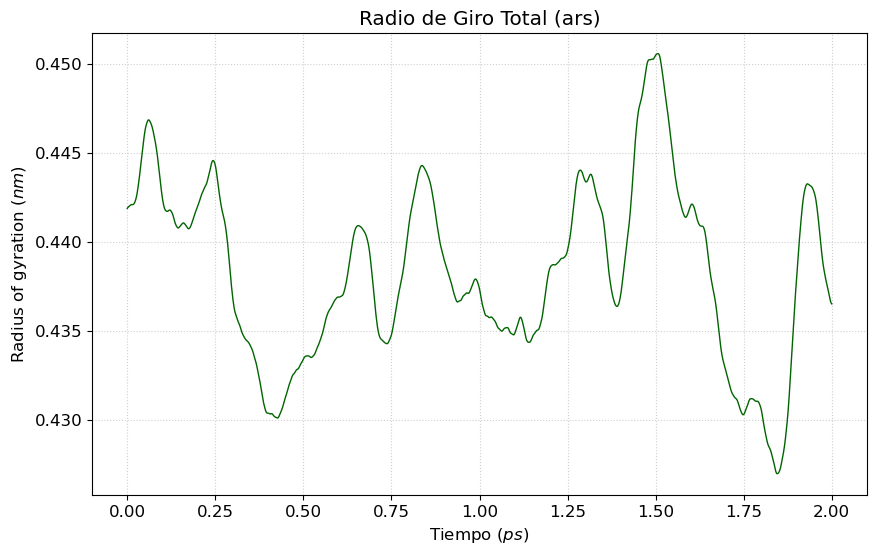

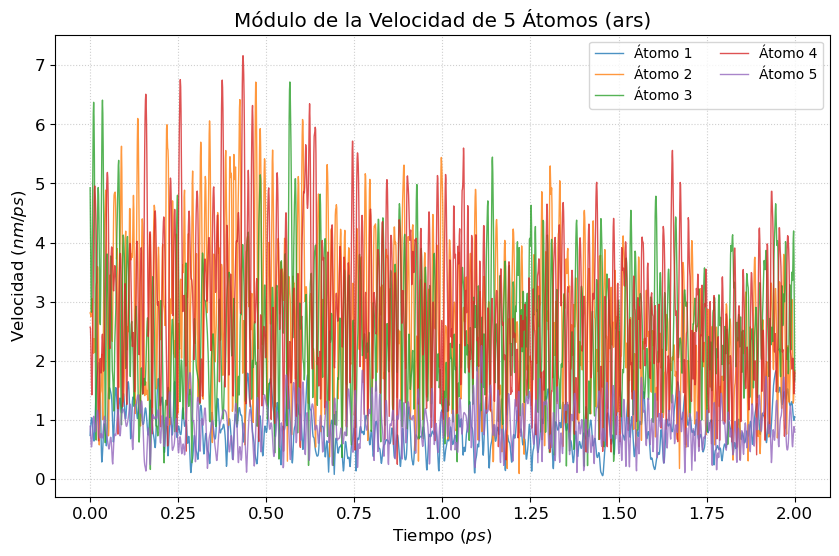

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Configuración para gráficas de alta calidad para LaTeX
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6), 'savefig.dpi': 300})

def plot_gmx_data(file_path, title, ylabel, xlabel='Tiempo ($ps$)', color='blue', label=None, select_cols=None):
    """Limpia y grafica archivos .xvg seleccionando columnas específicas si es necesario"""
    if not os.path.exists(file_path):
        print(f"Archivo no encontrado: {file_path}")
        return

    # Cargar datos ignorando comentarios (# y @)
    data = np.loadtxt(file_path, comments=['#', '@'])
    
    x = data[:, 0]
    y_data = data[:, 1:] # Todas las columnas de datos
    
    # Si se especifican columnas, las filtramos
    if select_cols is not None:
        y_data = y_data[:, select_cols]
    
    plt.figure()
    # Si hay más de una columna (caso de las velocidades), iteramos para graficar cada átomo
    if y_data.ndim > 1 and y_data.shape[1] > 1:
        for i in range(y_data.shape[1]):
            plt.plot(x, y_data[:, i], alpha=0.8, linewidth=1, label=f"{label} {i+1}")
        plt.legend(loc='upper right', fontsize='small', ncol=2)
    else:
        plt.plot(x, y_data, color=color, linewidth=1, label=label)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Guardado automático con el nombre del archivo original
    file_name = os.path.basename(file_path).replace('.xvg', '.png')
    plt.savefig(file_name, bbox_inches='tight')
    plt.show()

# --- RUTAS Y EJECUCIÓN ---
# Asegúrate de que la ruta termina en /
base_path = r'C:/Users/anton/Desktop/Master/Segundo cuatri/ModeladoMolecular/Tarea/Tarea/400k/4-analysis4/'

# 1. TEMPERATURA
plot_gmx_data(base_path + 'temp.xvg', 'Evolución de la Temperatura (ars)', 'Temperatura ($K$)', color='crimson')

# 2. RADIO DE GIRO (Sólo Rg Total)
# El índice 0 corresponde a la primera columna de datos (Rg Total)
plot_gmx_data(base_path + 'gyrate.xvg', 
              'Radio de Giro Total (ars)', 
              'Radius of gyration ($nm$)', 
              color='darkgreen', 
              label='Rg Total', 
              select_cols=[0])

# 3. VELOCIDADES DE 5 ÁTOMOS (Solo módulos |v|)
# Índices 3, 7, 11, 15, 19 corresponden a los módulos |v| de cada átomo en el archivo veloc.xvg
normas_indices = [3, 7, 11, 15, 19]
plot_gmx_data(base_path + 'veloc.xvg', 
              'Módulo de la Velocidad de 5 Átomos (ars)', 
              'Velocidad ($nm/ps$)', 
              label='Átomo', 
              select_cols=normas_indices)

Gráfica guardada como: energia_cinética_ars.png


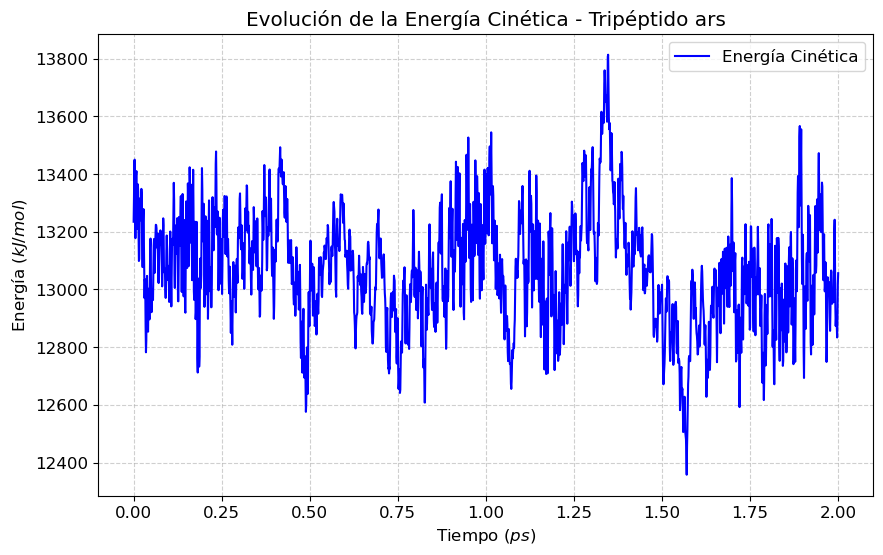

In [12]:
#####Energia 298

plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

def plot_energy_evolution(file_path, energy_name="Cinética"):
    try:
        # Cargar datos ignorando los encabezados de GROMACS (# y @) 
        data = np.loadtxt(file_path, comments=['#', '@'])
        
        # Columna 0: Tiempo (ps) 
        # Columna 1: Energía (kJ/mol) 
        time = data[:, 0]
        energy = data[:, 1]
        
        plt.figure()
        plt.plot(time, energy, color='blue', linewidth=1.5, label=f'Energía {energy_name}')
        
        # Etiquetas y títulos 
        plt.title(f'Evolución de la Energía {energy_name} - Tripéptido ars')
        plt.xlabel('Tiempo ($ps$)')
        plt.ylabel('Energía ($kJ/mol$)')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        
        # Guardar la imagen para el informe
        output_name = f"energia_{energy_name.lower()}_ars.png"
        plt.savefig(output_name, dpi=300, bbox_inches='tight')
        print(f"Gráfica guardada como: {output_name}")
        plt.show()

    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

plot_energy_evolution('C:/Users/anton/Desktop/Master/Segundo cuatri/ModeladoMolecular/Tarea/Tarea/400k/4-analysis4/energy.xvg', energy_name="Cinética")

Gráfica guardada como: energia_total_ars.png


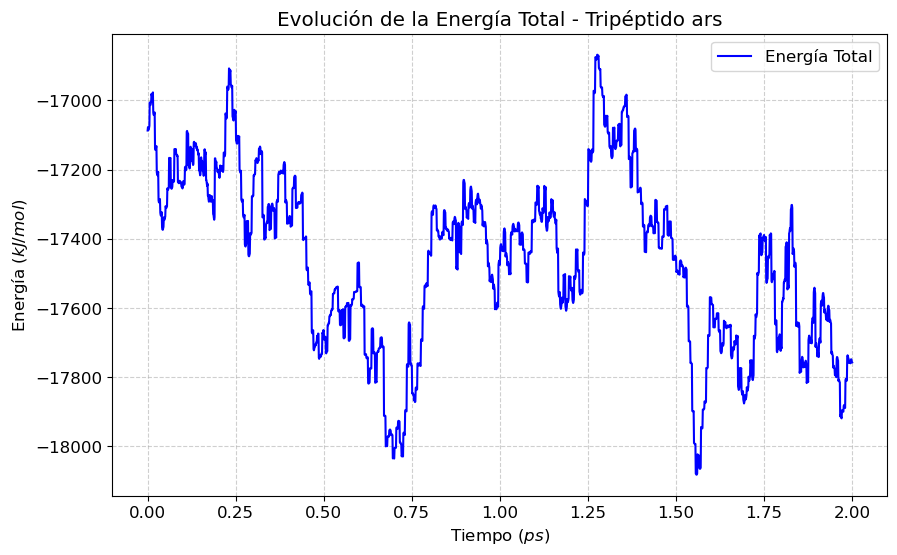

In [13]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

def plot_energy_evolution(file_path, energy_name="Total"):
    try:
        # Cargar datos ignorando los encabezados de GROMACS (# y @) 
        data = np.loadtxt(file_path, comments=['#', '@'])
        
        # Columna 0: Tiempo (ps) 
        # Columna 1: Energía (kJ/mol) 
        time = data[:, 0]
        energy = data[:, 1]
        
        plt.figure()
        plt.plot(time, energy, color='blue', linewidth=1.5, label=f'Energía {energy_name}')
        
        # Etiquetas y títulos 
        plt.title(f'Evolución de la Energía {energy_name} - Tripéptido ars')
        plt.xlabel('Tiempo ($ps$)')
        plt.ylabel('Energía ($kJ/mol$)')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        
        # Guardar la imagen para el informe
        output_name = f"energia_{energy_name.lower()}_ars.png"
        plt.savefig(output_name, dpi=300, bbox_inches='tight')
        print(f"Gráfica guardada como: {output_name}")
        plt.show()

    except Exception as e:
        print(f"Error al procesar el archivo: {e}")

plot_energy_evolution('C:/Users/anton/Desktop/Master/Segundo cuatri/ModeladoMolecular/Tarea/Tarea/400k/4-analysis4/energytotal.xvg', energy_name="Total")

########################################################################################################################################################